In [23]:
import torch
import numpy as np
import os
import matplotlib.pyplot as plt
import glob
from tqdm import tqdm
from Messy_data_Training_conditional_score import ConditionalScoreNet,  hyvarinen_loss

In [24]:
def compute_hyvarinen_score(model, x, y, device):
    """
    Compute Hyvärinen score S_H(y,x;θ) — memory-safe evaluation version.
    """
    model.eval()
    x = x.to(device)
    y = y.clone().detach().to(device).requires_grad_(True)

    with torch.set_grad_enabled(True):
        psi = model(x, y)
        loss1 = 0.5 * (psi ** 2).sum(dim=1)

        grads = []
        # disable graph creation for memory efficiency
        for i in range(psi.shape[1]):
            grad = torch.autograd.grad(
                psi[:, i].sum(),
                y,
                create_graph=False,   #  changed
                retain_graph=True      # keep current batch alive
            )[0][:, i]
            grads.append(grad)

        divergence = torch.stack(grads, dim=1).sum(dim=1)
        H_score = loss1 + divergence

    return H_score.detach()  # detach from autograd graph


In [35]:

# ============================================================
# Settings
# ============================================================
d = 10
N_pre, N_post = 120, 80
eps = 0.1
x0 = np.zeros(d, dtype=np.float32)

# Pre- and post-change parameters
P0 = {"alpha": 0.3, "dt": 0.05, "sigma": 0.3, "shift": 0.2}  # kernel 1
P1 = {"alpha": 0.6, "dt": 0.05, "sigma": 0.5, "shift": 0.9}  # kernel 2

# ============================================================
# Dynamics
# ============================================================
def f(x, alpha):
    return alpha * np.tanh(x)

def sample_Y_given_X(x, alpha, dt, sigma, shift):
    gradV = (x - shift) / np.sqrt((x - shift)**2 + eps**2)
    drift = f(x, alpha) - gradV
    noise = sigma * np.sqrt(dt) * np.random.randn(len(x))
    return x + dt * drift + noise

# ============================================================
# Generate and save combined chain
# ============================================================
def generate_combined_chain(x0, P0, P1, N_pre, N_post):
    x = x0.copy()
    chain = np.zeros((N_pre + N_post, len(x)), dtype=np.float32)

    print(f"\n--- Synthesizing combined Markov chain ---")
    print(f"Pre-change kernel: alpha={P0['alpha']}, sigma={P0['sigma']}, shift={P0['shift']}")
    print(f"Post-change kernel: alpha={P1['alpha']}, sigma={P1['sigma']}, shift={P1['shift']}")
    print(f"Lengths: pre={N_pre}, post={N_post}\n")

    for i in tqdm(range(N_pre), desc="Pre-change segment"):
        x = sample_Y_given_X(x, **P0)
        chain[i] = x

    for i in tqdm(range(N_post), desc="Post-change segment"):
        x = sample_Y_given_X(x, **P1)
        chain[N_pre + i] = x

    filename = f"combined_markov_chain_pre{N_pre}_post{N_post}.pt"
    torch.save(torch.from_numpy(chain), filename)
    print(f"\n[OK] Combined chain saved to: {filename}")
    return filename

# ============================================================
# Run
# ============================================================
if __name__ == "__main__":
    path = generate_combined_chain(x0, P0, P1, N_pre, N_post)
    print(f"\nSaved combined chain path: {path}")



--- Synthesizing combined Markov chain ---
Pre-change kernel: alpha=0.3, sigma=0.3, shift=0.2
Post-change kernel: alpha=0.6, sigma=0.5, shift=0.9
Lengths: pre=120, post=80



Post-change segment: 100%|██████████████████████████████████████████████████████████| 80/80 [00:00<00:00, 39620.30it/s]


[OK] Combined chain saved to: combined_markov_chain_pre120_post80.pt

Saved combined chain path: combined_markov_chain_pre120_post80.pt


Using device: cuda
Loaded combined chain: 199 pairs, dimension 10
Computing Hyvärinen scores for both models...

Saved score difference to: C:\Users\chenw\OneDrive - University of Pittsburgh\_score network code\Markov chain neumeric\non_Gaussian_chains\hybrid_score_difference_nonGaussian.pt


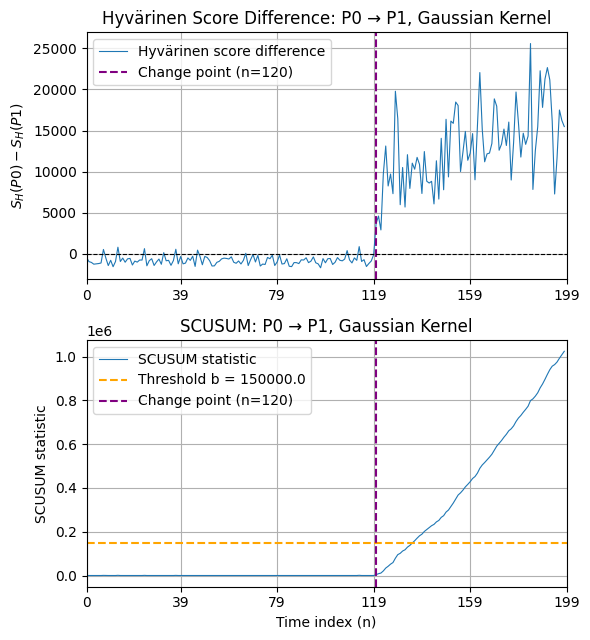

[Pre-change region]  Mean: -822.55
[Post-change region] Mean: 12964.70
Change detected at n = 136 (threshold b = 150000.0), delay = 16


In [47]:
# ============================================================
# Device setup
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ============================================================
# Paths and parameters
# ============================================================
DATA_DIR = os.getcwd()          # current directory
CHAIN_PATH = os.path.join(DATA_DIR, f"combined_markov_chain_pre{N_pre}_post{N_post}.pt")

P0_model_path = os.path.join(DATA_DIR,
    "markov_chain_alpha_0.30_dt_0.05_sigma_0.30_shift_0.20_full_hidden128_layers3.pth")
P1_model_path = os.path.join(DATA_DIR,
    "markov_chain_alpha_0.60_dt_0.05_sigma_0.50_shift_0.90_full_hidden128_layers3.pth")

hidden_dim = 128
num_layers = 3
M = 1e5    # truncation level
CHANGE_POINT = N_pre

# ============================================================
# Load combined chain and form pairs
# ============================================================
X = torch.load(CHAIN_PATH).float().to(device)  # shape (N, d)
x_pairs = X[:-1]
y_pairs = X[1:]
N_pairs, d = x_pairs.shape
print(f"Loaded combined chain: {N_pairs} pairs, dimension {d}")

# ============================================================
# Load trained Conditional Score Networks
# ============================================================
model_P0 = ConditionalScoreNet(d, hidden_dim=hidden_dim, num_layers=num_layers).to(device)
model_P1 = ConditionalScoreNet(d, hidden_dim=hidden_dim, num_layers=num_layers).to(device)
model_P0.load_state_dict(torch.load(P0_model_path, map_location=device))
model_P1.load_state_dict(torch.load(P1_model_path, map_location=device))
model_P0.eval(); model_P1.eval()

# ============================================================
# Compute Hyvärinen scores and their difference
# ============================================================
with torch.no_grad():
    print("Computing Hyvärinen scores for both models...")
    score_p0 = compute_hyvarinen_score(model_P0, x_pairs, y_pairs, device)
    score_p1 = compute_hyvarinen_score(model_P1, x_pairs, y_pairs, device)

    diff_score = score_p0 - score_p1
    diff_score = torch.clamp(diff_score, min=-M, max=M)
    diff_score = diff_score.cpu().numpy()

# ============================================================
# Save difference
# ============================================================
out_path = os.path.join(DATA_DIR, "hybrid_score_difference_nonGaussian.pt")
torch.save(torch.tensor(diff_score), out_path)
print(f"\nSaved score difference to: {out_path}")

# ============================================================
# Plot Hyvärinen score difference
# ============================================================

b = 1.5e5
Z = 0.0
Z_list = []  # store Z values over time
stopping_time = None

for n in range(len(diff_score)):
    s_n = np.clip(diff_score[n], -M, M)
    Z = max(0.0, Z + s_n)
    Z_list.append(Z)

    if stopping_time is None and Z >= b:
        stopping_time = n  # record first threshold crossing

# Shared x-axis setup
x_min = 0
x_max = len(diff_score) 
xticks = np.linspace(x_min, x_max, num=6, dtype=int)
T0 = N_pre
# Create vertically stacked plots with shared x-axis
fig, axes = plt.subplots(2, 1, figsize=(6, 6.5), sharex=True)

# Plot 1: Hyvärinen score difference
axes[0].plot(diff_score, label="Hyvärinen score difference", lw=0.8)
axes[0].axvline(T0, color="purple", linestyle="--", label=f"Change point (n={T0})")
axes[0].axhline(0, color="black", linestyle="--", lw=0.8)
axes[0].set_ylabel(f"$S_H(P0) - S_H(P1)$")
axes[0].set_title(f"Hyvärinen Score Difference: P0 → P1, Gaussian Kernel")
axes[0].legend()
axes[0].grid(True)
axes[0].tick_params(labelbottom=True)  # <-- Show x-axis ticks for top plot

# Plot 2: SCUSUM
axes[1].plot(Z_list, label="SCUSUM statistic", lw=0.8)
axes[1].axhline(b, color="orange", linestyle="--", label=f"Threshold b = {b}")
axes[1].axvline(T0, color="purple", linestyle="--", label=f"Change point (n={T0})")
axes[1].set_xlabel("Time index (n)")
axes[1].set_ylabel("SCUSUM statistic")
axes[1].set_title(f"SCUSUM: P0 → P1, Gaussian Kernel")
axes[1].legend()
axes[1].grid(True)
axes[1].set_xlim(x_min, x_max)
axes[1].set_xticks(xticks)

plt.tight_layout()
plt.show()

# ============================================================
# Region-wise summary
# ============================================================
pre_mean = diff_score[:CHANGE_POINT].mean()
post_mean = diff_score[CHANGE_POINT:].mean()

print(f"[Pre-change region]  Mean: {pre_mean:.2f}")
print(f"[Post-change region] Mean: {post_mean:.2f}")

if stopping_time is not None:
    print(f"Change detected at n = {stopping_time} (threshold b = {b}), delay = {stopping_time - T0}")
else:
    print(f"No change detected (Z_n never crossed b = {b})")





In [263]:
# Assuming diff_score is a NumPy array or a PyTorch tensor


# # If diff_score is a PyTorch tensor, convert to NumPy
# if isinstance(diff_score, torch.Tensor):
#     diff_score = diff_score.cpu().numpy()

# # Slice the first 200 entries
# subset = diff_score[N_pre:]

# # Filter positive values
# positive_values = subset[subset > 0]

# # Display results
# print(f"Number of positive values : {len(positive_values)}")
# print("Positive values:")
# print(positive_values)



### Objective
In this experiment, we empirically verify the lower bound on the mean time to false alarm established in **Theorem V.2**:

$$
\mathbb{E}_\infty[T(b)] \ge \frac{2\sqrt{2}}{3}\exp\left(\frac{4\delta(b - \mu)}{\mu^2}\right),
$$
where the expectation $\mathbb{E}_\infty[\cdot]$ is taken under the pre-change regime $P_0$, meaning that all observations are generated from the Markov kernel $P_0$.

--- 

####  Empirical Estimation of $ \mathbb{E}_\infty[T(b)] $

   $$
   \mathbb{E}_\infty[T(b)] = \frac{1}{N}\sum_{i=1}^{N} T_b^{(i)}.
   $$



####  Comparison with the Theoretical Lower Bound
For each threshold $b$, compute the theoretical bound
$$
L(b) = \frac{2\sqrt{2}}{3}\exp\left(\frac{4\delta(b - \mu)}{\mu^2}\right),
$$
using the same $\delta$ and $\mu$ parameters defined in the theorem.

---

###  Computing the Constant μ in the False-Alarm Bound

$$
\mu = \frac{2(\tilde{l}+1)\|\phi\|}{\tilde{\lambda}}.
$$
For Doeblin's condition we have 
$$
P^{l} (x, \cdot ) \ge \lambda \phi (\cdot)
$$



In [264]:
# ============================================================
# General configuration
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

DATA_DIR = os.getcwd()  # current directory


# ============================================================
# Trained models (P0 and P1)
# ============================================================
P0_model_path = os.path.join(DATA_DIR,
    "markov_chain_alpha_0.30_dt_0.05_sigma_0.30_shift_0.20_full_hidden128_layers3.pth")
P1_model_path = os.path.join(DATA_DIR,
    "markov_chain_alpha_0.60_dt_0.05_sigma_0.50_shift_0.90_full_hidden128_layers3.pth")

# ============================================================
# Helper to compute score difference sequence
# ============================================================
def compute_score_diff(path_file, model_P0, model_P1, batch_size=32, M=200):
    """Compute Hyvärinen score difference sequence along a Markov path."""
    X = torch.load(path_file).float().to(device)
    x_pairs, y_pairs = X[:-1], X[1:]
    N_pairs = len(x_pairs)

    num_batches = int(np.ceil(N_pairs / batch_size))
    score_p0_list, score_p1_list = [], []

    with torch.no_grad():
        print(f"Computing Hyvärinen scores for {N_pairs} pairs...")
        for i in tqdm(range(num_batches), desc="Evaluating", ncols=90):
            start = i * batch_size
            end = min((i + 1) * batch_size, N_pairs)
            x_batch = x_pairs[start:end]
            y_batch = y_pairs[start:end]
            s0 = compute_hyvarinen_score(model_P0, x_batch, y_batch, device)
            s1 = compute_hyvarinen_score(model_P1, x_batch, y_batch, device)
            score_p0_list.append(s0)
            score_p1_list.append(s1)

    score_p0 = torch.cat(score_p0_list)
    score_p1 = torch.cat(score_p1_list)
    diff_score = score_p0 - score_p1
    # Detach before converting to numpy
    diff_score = torch.clamp(diff_score, min=-M, max=M).detach().cpu().numpy()

    return diff_score

# ============================================================
# Load models once
# ============================================================
print("Loading models...")
model_P0 = ConditionalScoreNet(d=10, hidden_dim=hidden_dim, num_layers=num_layers).to(device)
model_P1 = ConditionalScoreNet(d=10, hidden_dim=hidden_dim, num_layers=num_layers).to(device)
model_P0.load_state_dict(torch.load(P0_model_path, map_location=device))
model_P1.load_state_dict(torch.load(P1_model_path, map_location=device))
model_P0.eval()
model_P1.eval()

Using device: cuda
Loading models...


ConditionalScoreNet(
  (net): Sequential(
    (0): Linear(in_features=20, out_features=128, bias=True)
    (1): SiLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): SiLU()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): SiLU()
    (6): Linear(in_features=128, out_features=10, bias=True)
  )
)

In [265]:
def estimate_lambda_and_ell_from_scores(s, acf_maxlag=200, eta=0.05):
    # s: 1D numpy array of truncated score differences under P0
    s = s - s.mean()
    N = len(s)
    # unbiased ACF up to acf_maxlag
    acf = np.array([np.dot(s[:N-k], s[k:]) / np.dot(s, s) for k in range(acf_maxlag+1)])
    # use positive lags where acf is positive and decaying
    ks = np.arange(1, acf_maxlag+1)
    mask = acf[1:] > 0
    ks_fit = ks[mask]
    acf_fit = acf[1:][mask]
    # avoid zeros
    acf_fit = np.clip(acf_fit, 1e-12, None)
    # linear fit to log(acf) = a - lambda * k
    A = np.vstack([np.ones_like(ks_fit), -ks_fit]).T
    params, _, _, _ = np.linalg.lstsq(A, np.log(acf_fit), rcond=None)
    a_hat, lambda_hat = params[0], params[1]  # lambda_hat > 0
    # pick ell via threshold
    ell_hat = int(np.ceil(np.log(1/eta) / lambda_hat))
    return float(lambda_hat), int(ell_hat), acf

Computing Hyvärinen scores for 999999 pairs...


Evaluating: 100%|███████████████████████████████████| 31250/31250 [05:38<00:00, 92.32it/s]


Saved score diffence to .pt file


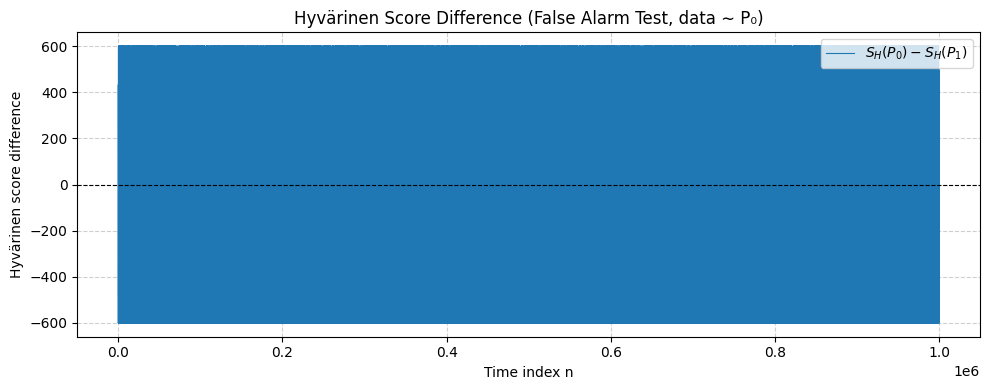


=== False Alarm Test (data ∼ P₀) ===
Mean diff_score = -513.1243, Estimated δ = 513.1243, |phi|= 600.0
Theoretically, we get: 
 lambda_tilde ≈ 0.0029, ell_tilde = 1045, mu ≈ 437610078.65


In [165]:
M = 600.0           # truncation level
# ---- 1. FALSE ALARM EXPERIMENT (no change; path ~ P0) ----
# ============================================================

path_P0 = os.path.join(DATA_DIR, "1M_long_P_0_0.30_dt_0.05_sigma_0.30_shift_0.20_full.pt")

diff_score_P0 = compute_score_diff(
    path_file=path_P0,
    model_P0=model_P0,
    model_P1=model_P1,
    batch_size=batch_size,
    M=M 
)
torch.save(torch.tensor(diff_score_P0),
           os.path.join(DATA_DIR, f"100M_{M}_score_difference_false_alarm.pt"))
print("Saved score diffence to .pt file")


# # Load the .pt file
# diff_score_P0 = torch.load("1M_600.0_score_difference_false_alarm.pt")


# # ---- Plot the score difference ----
# plt.figure(figsize=(10, 4))
# plt.plot(diff_score_P0, lw=0.8, label=r"$S_H(P_0) - S_H(P_1)$")
# plt.axhline(0, color="black", linestyle="--", lw=0.8)
# plt.xlabel("Time index n")
# plt.ylabel("Hyvärinen score difference")
# plt.title("Hyvärinen Score Difference (False Alarm Test, data ∼ P₀)")
# plt.grid(True, linestyle="--", alpha=0.6)
# plt.legend()
# plt.tight_layout()
# plt.show()

estimated_delta = abs(diff_score_P0.mean())

print("\n=== False Alarm Test (data ∼ P₀) ===")
print(f"Mean diff_score = {diff_score_P0.mean():.4f}, Estimated δ = {estimated_delta:.4f}, |phi|= {M}")

# diff_score_P0 = ...  # your truncated sequence under P0 as numpy array
lambda_tilde, ell_tilde, acf = estimate_lambda_and_ell_from_scores(diff_score_P0, acf_maxlag=300, eta=0.05)
mu_hat = 2.0 * (ell_tilde + 1.0) * M / max(lambda_tilde, 1e-12)
print(f"Theoretically, we get: \n lambda_tilde ≈ {lambda_tilde:.4f}, ell_tilde = {ell_tilde}, mu ≈ {mu_hat:.2f}")


=== False Alarm Delay vs Threshold ===
estimated_mu = 1230.00, estimated_delta =513.124268, M =600.0 
     b    E₀[T(b)]      L(b) Lower Bound
1305.0    34523.88                  1.04
1380.0    49867.83                  1.16
1455.0    64115.79                  1.28
1530.0    89762.10                  1.42
1605.0    99735.67                  1.57
1680.0    99735.67                  1.74
1755.0   112202.62                  1.92
1830.0   224405.50                  2.13
1905.0   299207.33                  2.36
1980.0   448811.00                  2.61


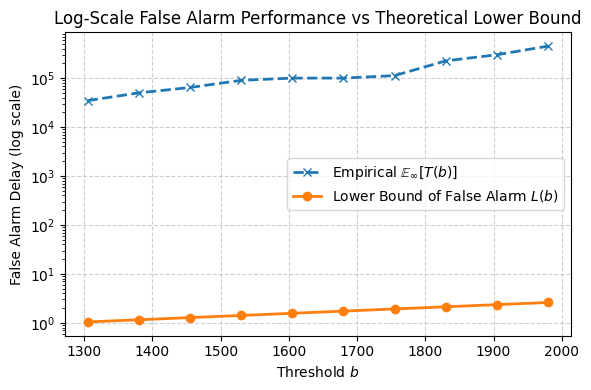

In [267]:
burn_in = 100          
estimated_mu = 2.05*M
batch_size = 32            # adjust if memory is tight
num_points = 10
delta = 75
thresholds = [estimated_mu + i * delta for i in range(1, num_points+1)]


# -----------------------------
# Evaluate E0[T(b)] and L(b)
# -----------------------------
results = []
for b in thresholds:
    Z = 0.0
    last_alarm = burn_in
    false_alarms = []

    for n in range(burn_in, len(diff_score_P0)):
        s_n = diff_score_P0[n]
        Z = max(0.0, Z + s_n)
        if Z >= b:
            false_alarms.append(n - last_alarm)
            last_alarm = n
            Z = 0.0  # reset CUSUM

    false_alarms = np.array(false_alarms)
    E_Tb = false_alarms.mean() if len(false_alarms) > 0 else np.nan
    L_b = (2 * np.sqrt(2) / 3) * np.exp((4 * estimated_delta * (b - estimated_mu)) / (estimated_mu**2))

    results.append((b, E_Tb, L_b))

# -----------------------------
# Display results
# -----------------------------
print("\n=== False Alarm Delay vs Threshold ===")
print(f"estimated_mu = {estimated_mu:.2f}, estimated_delta ={estimated_delta:2f}, M ={M} ")
print(f"{'b':>6}  {'E₀[T(b)]':>10}  {'L(b) Lower Bound':>20}")
for b, E_Tb, L_b in results:
    print(f"{b:6.1f}  {E_Tb:10.2f}  {L_b:20.2f}")

# -----------------------------
# Plot E0[T(b)] vs L(b)
# -----------------------------
b_vals = [r[0] for r in results]
E0_Tb_vals = [r[1] for r in results]
L_b_vals = [r[2] for r in results]

plt.figure(figsize=(6, 4))
plt.plot(b_vals, E0_Tb_vals, 'x--', lw=2, label=r"Empirical $\mathbb{E}_\infty[T(b)]$")
plt.plot(b_vals, L_b_vals, 'o-', lw=2, label=r"Lower Bound of False Alarm $L(b)$")
plt.xlabel("Threshold $b$")
plt.ylabel("False Alarm Delay (log scale)")  # <-- updated y-label
plt.yscale("log")
plt.title("Log-Scale False Alarm Performance vs Theoretical Lower Bound")  # <-- updated title
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


In [268]:
# ----if not truncated (no change; path ~ P0) ----
# ============================================================

diff_score_P0_no_truncation = compute_score_diff(
    path_file=path_P0,
    model_P0=model_P0,
    model_P1=model_P1,
    batch_size=batch_size,
    M=1e9
)


# -----------------------------
# Evaluate E0[T(b)] and L(b)
# -----------------------------
results_no_truncation = []
for b in thresholds:
    Z = 0.0
    last_alarm = burn_in
    false_alarms_no_trun = []

    for n in range(burn_in, len(diff_score_P0_no_truncation)):
        s_n = diff_score_P0_no_truncation[n]
        Z = max(0.0, Z + s_n)
        if Z >= b:
            false_alarms_no_trun.append(n - last_alarm)
            last_alarm = n
            Z = 0.0  # reset CUSUM

    false_alarms_no_trun = np.array(false_alarms_no_trun)
    E_Tb_no_trun = false_alarms_no_trun.mean() if len(false_alarms_no_trun) > 0 else np.nan
    L_b = (2 * np.sqrt(2) / 3) * np.exp((4 * estimated_delta * (b - estimated_mu)) / (estimated_mu**2))

    results_no_truncation.append((b, E_Tb_no_trun, L_b))

Computing Hyvärinen scores for 999999 pairs...


Evaluating: 100%|███████████████████████████████████| 31250/31250 [05:37<00:00, 92.57it/s]



=== False Alarm Delay vs Threshold ===
estimated_mu = 1230.00, estimated_delta =513.124268, M =600.0 
     b  E₀[T(b) no trun]      L(b) Lower Bound
1305.0     1290.41                  1.04
1380.0     1618.76                  1.16
1455.0     2089.49                  1.28
1530.0     2706.70                  1.42
1605.0     3362.32                  1.57
1680.0     4235.09                  1.74
1755.0     5408.95                  1.92
1830.0     7108.90                  2.13
1905.0     9047.69                  2.36
1980.0    11182.54                  2.61


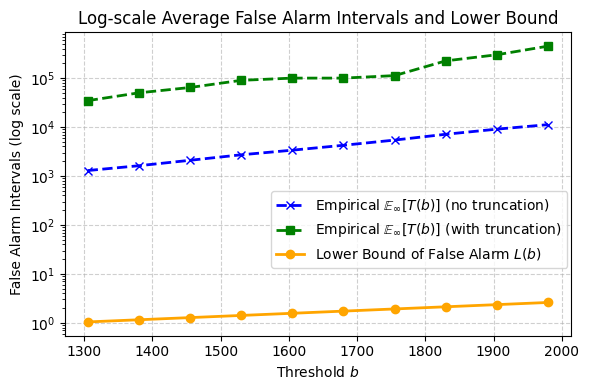

In [253]:
# -----------------------------
# Display results
# -----------------------------
print("\n=== False Alarm Delay vs Threshold ===")
print(f"estimated_mu = {estimated_mu:.2f}, estimated_delta ={estimated_delta:2f}, M ={M} ")
print(f"{'b':>6}  {'E₀[T(b) no trun]':>10}  {'L(b) Lower Bound':>20}")
for b, E_Tb_no_trun_Tb, L_b in results_no_truncation:
    print(f"{b:6.1f}  {E_Tb_no_trun_Tb:10.2f}  {L_b:20.2f}")

# -----------------------------
# Plot E0[T(b)] vs L(b)
# -----------------------------
b_vals = [r[0] for r in results_no_truncation]
E0_Tb_vals_no_trun = [r[1] for r in results_no_truncation]
L_b_vals = [r[2] for r in results_no_truncation]

plt.figure(figsize=(6, 4))

plt.plot(b_vals, E0_Tb_vals_no_trun, 'x--', color='blue', lw=2,
         label=r"Empirical $\mathbb{E}_\infty[T(b)]$ (no truncation)")
plt.plot(b_vals, E0_Tb_vals, 's--', color='green', lw=2,
         label=r"Empirical $\mathbb{E}_\infty[T(b)]$ (with truncation)")
plt.plot(b_vals, L_b_vals, 'o-', color='orange', lw=2,
         label=r"Lower Bound of False Alarm $L(b)$")

plt.xlabel("Threshold $b$")
plt.ylabel("False Alarm Intervals (log scale)")
plt.yscale("log")
plt.title("Log-scale Average False Alarm Intervals and Lower Bound")
plt.legend(loc="upper center", bbox_to_anchor=(0.7, 0.50))


plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


 ### Comments on the False Alarm Neumerics
 Based on my analysis, the $\mu$ is large, in the lower bound I computed,  I set $b>\mu$. But if I set like this, I will never encounter a false alarm. 

## Numerical Verification of the Detection Delay Bound

### Objective

Verify if 
$$
\mathbb{E}_1[T(b)] \le 1 + \left\lfloor \frac{b + \mu}{I} \right\rfloor (1 + o(1)),
$$

where:
- $ T(b) $ is the stopping time defined by your detection rule.
- $ \mu $ is a bound on the score-difference increments.
- $ I = \mathbb{E}_1\left[ S_H(X_t, X_{t-1}; P_0) - S_H(X_t, X_{t-1}; P_1) \right] $ is the **positive drift** of the score difference under $ P_1 $.

---

####  Empirical Estimation of Detection Delay
For each value of threshold $b$:

1. Apply the stopping rule to a path of 1000 data, each time when we get triger an alarm, we to get $ T_b^{(i)} $, the i-th stopping, and then we reset the CUSUM to 0. 
2. the datapath is P_1_delay_0.60_dt_0.05_sigma_0.50_shift_0.90_full.pt
3. Compute the empirical mean:
   $$
   \mathbb{E}_1[T(b)]= \frac{1}{N} \sum_{i=1}^{N} T_b^{(i)}.
   $$

Repeat this process for multiple values of $ b $ (e.g., $ b = 1200, 1400, 1600, 1800, 2000 $).


###  Compare with Theoretical Bound

For each $ b $, compute the theoretical upper bound:
$$
U(b) = 1 + \left\lfloor \frac{b + \mu}{I} \right\rfloor,
$$
where:
- $ \mu $ is the maximum absolute increment of the score difference.
- $ I $ is the empirical average drift of the score difference under $P_1$, computed from:
  $$
  I \approx \frac{1}{N} \sum_{t=1}^N \Delta S_t \quad \text{(averaged over one or more $P_1$ trajectories)}.
  $$

---

### Plotting

- **x-axis:** threshold $b$
- **y-axis:** empirical and theoretical delay
  - Blue line: empirical delay $ \mathbb{E}_1[T(b)]$
  - Red dashed line: theoretical upper bound $ U(b) $

The empirical curve should grow roughly **linearly** in $b$, confirming the prediction from Theorem VI.1.

---

### Notes

- All samples used here must be from $P_1$, i.e., **immediate change-point** at $\nu = 0$.
- This validates that the algorithm **reacts quickly** when the change has occurred.
- The linear behavior is in contrast with the **exponential false-alarm time** under $P_0$.


In [255]:
path_P1    = os.path.join(DATA_DIR, "P_1_delay_0.60_dt_0.05_sigma_0.50_shift_0.90_full.pt")

batch_size = 32            # adjust if memory is tight
num_points = 10
delta = 5*M
thresholds = [estimated_mu + i * delta for i in range(0, num_points )]

# ============================
# Load models
# ============================
d = 10

# Compute Hyvärinen score difference with truncation
diff_score_P1 = compute_score_diff(
    path_file=path_P1,
    model_P0=model_P0,
    model_P1=model_P1,
    batch_size=batch_size,
    M=M 
)
I = np.mean(diff_score_P1)
print(f"Average of truncated score difference I = {I:.2f}")

torch.save(torch.tensor(diff_score_P1),
           os.path.join(DATA_DIR, "score_difference_delay_P_1.pt"))
print("Saved: score_difference_delay_P_1.pt")


Computing Hyvärinen scores for 9999 pairs...


Evaluating: 100%|███████████████████████████████████████| 313/313 [00:03<00:00, 88.45it/s]

Average of truncated score difference I = 599.89
Saved: score_difference_delay_P_1.pt


b=1230.0: alarms=79, average detection delay E1[T(b)]=2.52, theoretical upper bound U(b)=5.0
b=4230.0: alarms=77, average detection delay E1[T(b)]=2.58, theoretical upper bound U(b)=10.0
b=7230.0: alarms=73, average detection delay E1[T(b)]=2.73, theoretical upper bound U(b)=15.0
b=10230.0: alarms=60, average detection delay E1[T(b)]=3.32, theoretical upper bound U(b)=20.0
b=13230.0: alarms=52, average detection delay E1[T(b)]=3.83, theoretical upper bound U(b)=25.0
b=16230.0: alarms=43, average detection delay E1[T(b)]=4.63, theoretical upper bound U(b)=30.0
b=19230.0: alarms=38, average detection delay E1[T(b)]=5.24, theoretical upper bound U(b)=35.0
b=22230.0: alarms=35, average detection delay E1[T(b)]=5.69, theoretical upper bound U(b)=40.0
b=25230.0: alarms=31, average detection delay E1[T(b)]=6.42, theoretical upper bound U(b)=45.0
b=28230.0: alarms=28, average detection delay E1[T(b)]=7.11, theoretical upper bound U(b)=50.0


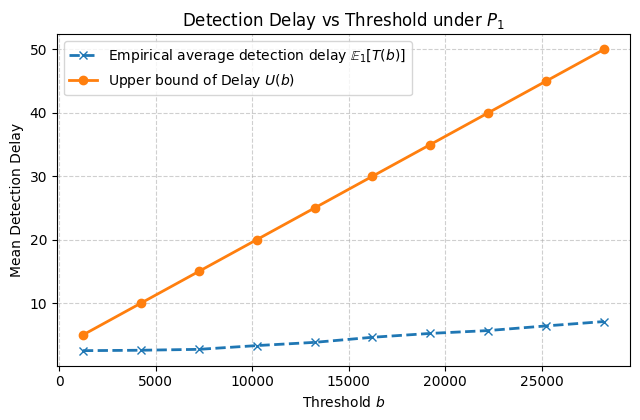

In [256]:
# ============================
# CUSUM with reset; collect T_b^{(i)} across one long path
# ============================
def cusum_delays_with_reset(seq, b):
    """Return list of T_b^{(i)} from one long sequence, resetting Z→0 after each alarm."""
    Z = 0.0
    t_since_reset = 0
    delays = []
    for s in seq:
        t_since_reset += 1
        Z = max(0.0, Z + float(s))
        if Z >= b:
            delays.append(t_since_reset)
            Z = 0.0
            t_since_reset = 0
    return delays

# ============================
# Theoretical upper bound U(b)
# ============================
def U_of_b(b, I, estimated_mu):
    if I <= 0:
        return float("inf")
    return 1.0 + np.floor((b + estimated_mu) / I)

# Compute empirical E1[T(b)] and theoretical U(b) for each b using one long P1 path
E1_Tb = {}
U_b = {}
for b in thresholds:
    delays = cusum_delays_with_reset(diff_score, b)
    E1_Tb[b] = float(np.mean(delays)) if len(delays) > 0 else float("nan")
    U_b[b] = U_of_b(b, I, estimated_mu)
    print(f"b={b}: alarms={len(delays)}, average detection delay E1[T(b)]={E1_Tb[b]:.2f}, theoretical upper bound U(b)={U_b[b]}")
# ============================
# Plots
# ============================
plt.figure(figsize=(6.5, 4.3))

# Empirical detection delay
plt.plot(thresholds, [E1_Tb[b] for b in thresholds], 'x--', lw=2,
         label=r"Empirical average detection delay $\mathbb{E}_1[T(b)]$")

# Theoretical upper bound using U_of_b
plt.plot(thresholds, [U_b[b] for b in thresholds], 'o-', lw=2,
         label=r"Upper bound of Delay $U(b)$")

plt.xlabel(r"Threshold $b$")
plt.ylabel(r"Mean Detection Delay")
plt.title("Detection Delay vs Threshold under $P_1$")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()




In [257]:
# Compute Hyvärinen score difference with truncation
diff_score_P1_no_trun = compute_score_diff(
    path_file=path_P1,
    model_P0=model_P0,
    model_P1=model_P1,
    batch_size=batch_size,
    M=1e9 
)

Computing Hyvärinen scores for 9999 pairs...


Evaluating: 100%|███████████████████████████████████████| 313/313 [00:03<00:00, 82.27it/s]


b=1230.0: alarms=28, average detection delay no trun E1[T(b)]=1.00, theoretical upper bound U(b)=5.0
b=4230.0: alarms=28, average detection delay no trun E1[T(b)]=1.01, theoretical upper bound U(b)=10.0
b=7230.0: alarms=28, average detection delay no trun E1[T(b)]=1.09, theoretical upper bound U(b)=15.0
b=10230.0: alarms=28, average detection delay no trun E1[T(b)]=1.26, theoretical upper bound U(b)=20.0
b=13230.0: alarms=28, average detection delay no trun E1[T(b)]=1.49, theoretical upper bound U(b)=25.0
b=16230.0: alarms=28, average detection delay no trun E1[T(b)]=1.73, theoretical upper bound U(b)=30.0
b=19230.0: alarms=28, average detection delay no trun E1[T(b)]=1.96, theoretical upper bound U(b)=35.0
b=22230.0: alarms=28, average detection delay no trun E1[T(b)]=2.19, theoretical upper bound U(b)=40.0
b=25230.0: alarms=28, average detection delay no trun E1[T(b)]=2.41, theoretical upper bound U(b)=45.0
b=28230.0: alarms=28, average detection delay no trun E1[T(b)]=2.64, theoreti

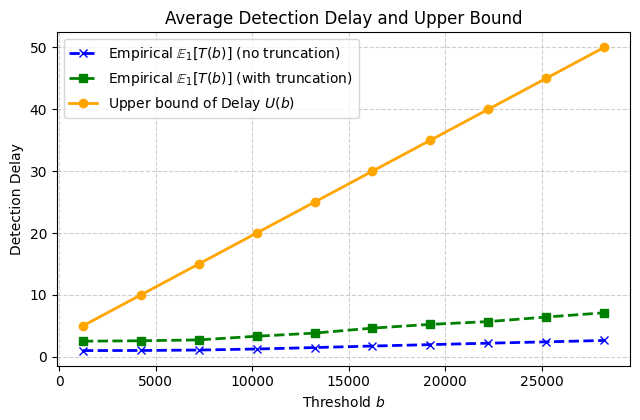

In [261]:
# Compute empirical E1[T(b)] and theoretical U(b) for each b using one long P1 path
E1_Tb_no_trunc = {}
U_b = {}
for b in thresholds:
    delays_no_trun = cusum_delays_with_reset(diff_score_P1_no_trun, b)
    E1_Tb_no_trunc[b] = float(np.mean(delays_no_trun)) if len(delays_no_trun) > 0 else float("nan")
    U_b[b] = U_of_b(b, I, estimated_mu)
    print(f"b={b}: alarms={len(delays)}, average detection delay no trun E1[T(b)]={E1_Tb_no_trunc[b]:.2f}, theoretical upper bound U(b)={U_b[b]}")
# ============================
# Plots
# ============================
plt.figure(figsize=(6.5, 4.3))

# Empirical detection delay

plt.plot(thresholds, [E1_Tb_no_trunc[b] for b in thresholds], 'x--', color='blue', lw=2,
         label=r"Empirical $\mathbb{E}_1[T(b)]$ (no truncation)")
plt.plot(thresholds, [E1_Tb[b] for b in thresholds], 's--', color='green', lw=2,
         label=r"Empirical $\mathbb{E}_1[T(b)]$ (with truncation)")

# Theoretical upper bound using U_of_b
plt.plot(thresholds, [U_b[b] for b in thresholds], 'o-', color='orange', lw=2,
         label=r"Upper bound of Delay $U(b)$")

plt.xlabel(r"Threshold $b$")
plt.ylabel(r"Detection Delay")
plt.title("Average Detection Delay and Upper Bound")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()